In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import cross_val_score, KFold, train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error
import math

## Загрузка данных
Описание: Загрузка датасета из CSV-файла и просмотр первых 5 строк для ознакомления со структурой данных.


In [3]:
df = pd.read_csv('employee_income.csv')
df.head()

,age,experience,income
0,50,5,45118
1,36,9,41691
2,29,3,35994
3,42,5,41614
4,40,12,51474


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   age         50 non-null     int64
 1   experience  50 non-null     int64
 2   income      50 non-null     int64
dtypes: int64(3)
memory usage: 1.3 KB


In [5]:
df['age_of_first_work'] = df.age - df.experience

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 4 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   age                50 non-null     int64
 1   experience         50 non-null     int64
 2   income             50 non-null     int64
 3   age_of_first_work  50 non-null     int64
dtypes: int64(4)
memory usage: 1.7 KB


C:\Users\dench\AppData\Local\Temp\ipykernel_17804\1020487225.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


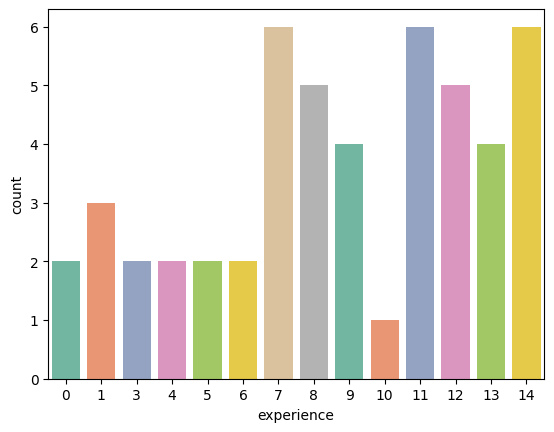

In [25]:
sns.countplot(
    data=df,
    x="experience",
    palette="Set2"
)
plt.show()

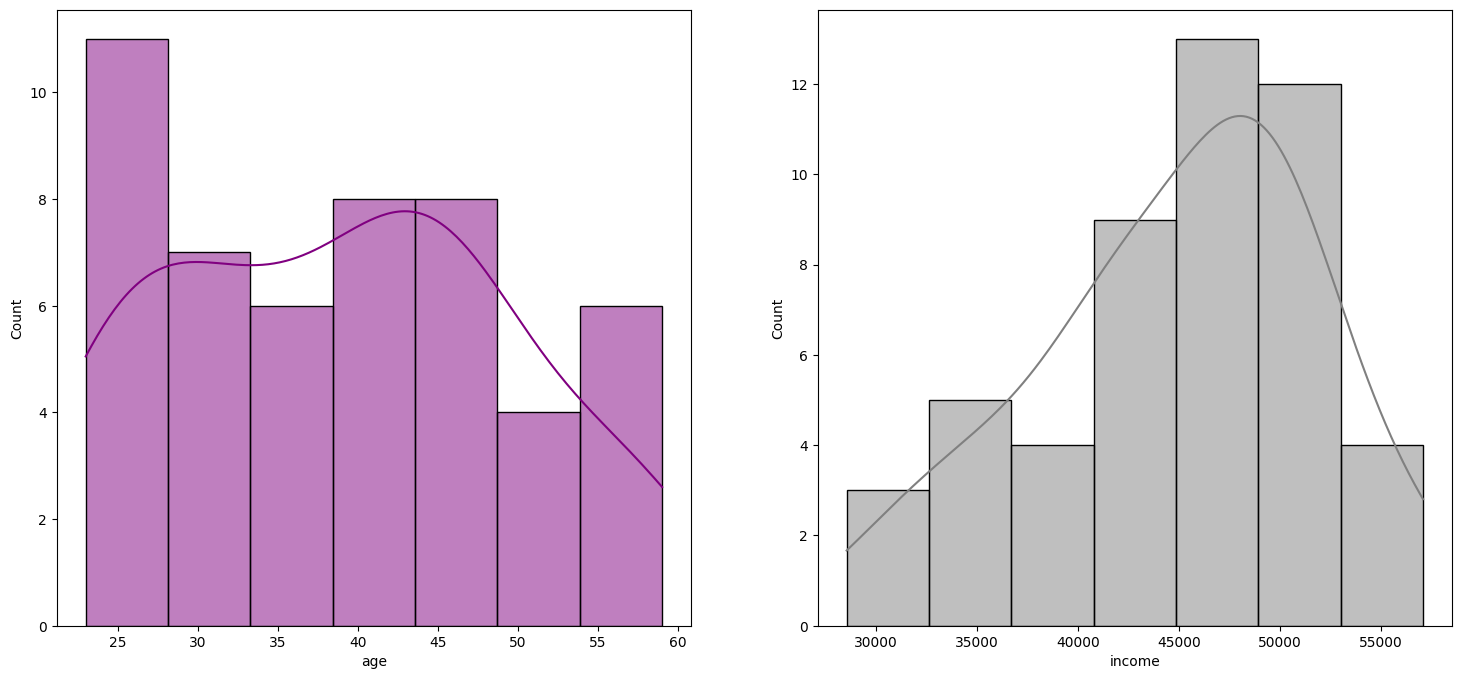

In [26]:
plt.figure(figsize=(18,8))

plt.subplot(1,2,1)
sns.histplot(
    data=df,
    x="age",
    color="purple",
    kde=True
)

plt.subplot(1,2,2)
sns.histplot(
    data=df,
    x="income",
    color="gray",
    kde=True
)
plt.show()

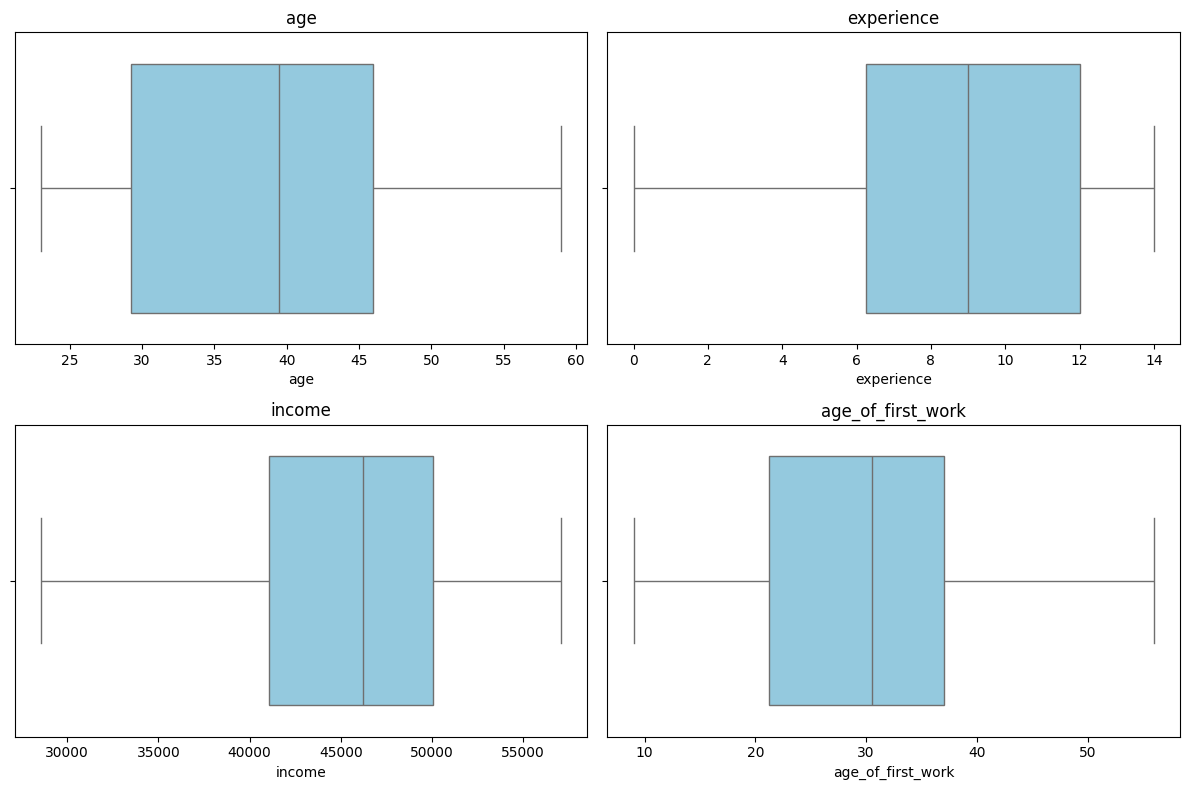

In [29]:
cols = df.columns
n_cols = 2
n_rows = math.ceil(len(cols) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(12, 4 * n_rows))
axes = axes.flatten()

for i, col in enumerate(cols):
    sns.boxplot(
        data=df,
        x=col,
        ax=axes[i],
        color="skyblue"
    )
    axes[i].set_title(col)

for j in range(i + 1, len(axes)):
    axes[j].axis("off")

plt.tight_layout()
plt.show()

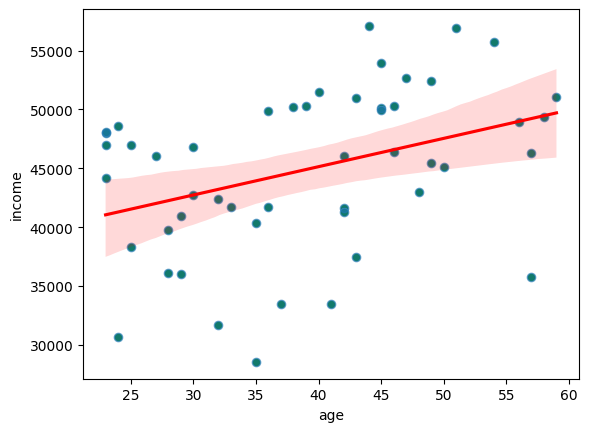

In [34]:
sns.scatterplot(
    data=df,
    x="age",
    y="income",
    color="green"
)
sns.regplot(
    data=df,
    x="age",
    y="income",
    scatter_kws={"alpha": 0.6},
    line_kws={"color": "red"}
)
plt.show()

In [7]:
corr_mat = df.corr(numeric_only=True)

<Axes: >

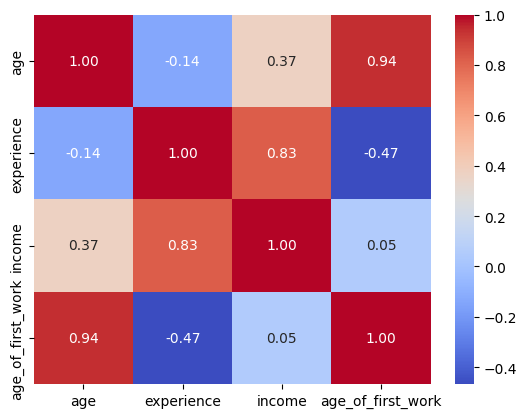

In [8]:
sns.heatmap(corr_mat, annot=True, cmap='coolwarm', fmt=".2f")

In [10]:
X = df.drop('income', axis = 1)
y = df.income             

In [19]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state=42)

In [20]:
model = LinearRegression()

In [21]:
model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [22]:
y_pred = model.predict(X_test)

In [24]:
mean_absolute_error(y_pred, y_test)

1581.4121026423504